In [1]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity

# ============================================================
# Single-site field operators from ladder operators
# ============================================================

def single_site_field_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Local Hilbert dimension
    # --------------------------------------------------------

    Nphi = 2**nq   # 64 for nq=6

    # --------------------------------------------------------
    # Ladder operator a
    # --------------------------------------------------------

    a = np.zeros((Nphi, Nphi), dtype=complex)

    for n in range(1, Nphi):

        a[n-1, n] = np.sqrt(n)

    # creation operator
    adag = a.conj().T

    # --------------------------------------------------------
    # Field operator
    #
    # Phi = (a + adag)/sqrt(2 mu)
    # --------------------------------------------------------

    Phi = (
        a + adag
    ) / np.sqrt(2 * mu)

    # --------------------------------------------------------
    # Conjugate momentum operator
    #
    # Pi = -i sqrt(mu/2) (a - adag)
    # --------------------------------------------------------

    Pi = (
        -1j
        * np.sqrt(mu / 2)
        * (a - adag)
    )

    # --------------------------------------------------------
    # Numerical Hermiticity cleanup
    # --------------------------------------------------------

    Phi = 0.5 * (Phi + Phi.conj().T)

    Pi = 0.5 * (Pi + Pi.conj().T)

    return csr_matrix(Phi), csr_matrix(Pi)


# ============================================================
# Two-site embedded operators
# ============================================================

def two_site_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(
        Nphi,
        format='csr',
        dtype=complex
    )

    # --------------------------------------------------------
    # Site 0 operators
    # --------------------------------------------------------

    Phi0 = kron(Phi, I, format='csr')
    Pi0  = kron(Pi,  I, format='csr')

    # --------------------------------------------------------
    # Site 1 operators
    # --------------------------------------------------------

    Phi1 = kron(I, Phi, format='csr')
    Pi1  = kron(I, Pi,  format='csr')

    return Phi0, Pi0, Phi1, Pi1


# ============================================================
# Example
# ============================================================

nq = 4
mu = 1.0

Phi0, Pi0, Phi1, Pi1 = two_site_operators(
    nq,
    mu
)

print("Hilbert dimension =", Phi0.shape[0])

print("Phi0 shape =", Phi0.shape)
print("Pi0 shape  =", Pi0.shape)

print("Phi1 shape =", Phi1.shape)
print("Pi1 shape  =", Pi1.shape)

Hilbert dimension = 256
Phi0 shape = (256, 256)
Pi0 shape  = (256, 256)
Phi1 shape = (256, 256)
Pi1 shape  = (256, 256)


In [2]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity
from scipy.sparse.linalg import eigsh

# ============================================================
# Local single-site Hamiltonian
# ============================================================

def single_site_hloc(Phi, Pi, mI2, lam, f):

    Phi2 = Phi @ Phi
    Phi4 = Phi2 @ Phi2
    Pi2  = Pi @ Pi

    hloc = (
        0.5 * Pi2
        + 0.5 * mI2 * Phi2
        + (lam / 24.0) * Phi4
        + f * Phi
    )

    return hloc




In [3]:
# ============================================================
# Two-site local Hamiltonian
# ============================================================

def two_site_hloc(nq, mu=1.0,
                  mI2=1.0,
                  lam=1.0,
                  f=1e-3):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    # --------------------------------------------------------
    # Single-site local Hamiltonian
    # --------------------------------------------------------

    hloc = single_site_hloc(Phi, Pi, mI2, lam, f)

    # --------------------------------------------------------
    # Two-site Hamiltonian
    # H = h ⊗ I + I ⊗ h
    # --------------------------------------------------------

    Hloc = (
        kron(hloc, I, format='csr')
        +
        kron(I, hloc, format='csr')
    )

    return Hloc




In [4]:
# ============================================================
# Exact ground state
# ============================================================

def ground_state(H):

    # smallest algebraic eigenvalue
    evals, evecs = eigsh(H, k=1, which='SA')

    E0 = evals[0]
    psi0 = evecs[:, 0]

    # normalize explicitly
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0




In [5]:
# ============================================================
# Example
# ============================================================

nq   = 4
mu   = 1.0
mI2  = 1.0
lam  = 1.0
f    = 1e-5

Hloc = two_site_hloc(
    nq=nq,
    mu=mu,
    mI2=mI2,
    lam=lam,
    f=f
)

E0_loc, psi_loc = ground_state(Hloc)

print("Ground-state energy =", E0_loc)
print("State dimension     =", psi_loc.shape)
print("Norm                =", np.linalg.norm(psi_loc))

Ground-state energy = 1.0554722545756816
State dimension     = (256,)
Norm                = 1.0


In [6]:
# ============================================================
# Convert scalar-field Hamiltonian to Pauli form

# ============================================================

from qiskit.quantum_info import Operator, SparsePauliOp

# ============================================================
# Build two-site Hamiltonian
# ============================================================

Hloc = two_site_hloc(
    nq=4,
    mu=1.0,
    mI2=1.0,
    lam=1.0,
    f=1e-5
)

# ============================================================
# Convert sparse matrix -> dense matrix
# ============================================================

H_dense = Hloc.toarray()

print("Dense Hamiltonian shape =", H_dense.shape)

# ============================================================
# Convert to Qiskit Operator
# ============================================================

H_op = Operator(H_dense)

# ============================================================
# Convert to SparsePauliOp
# ============================================================

print("\nConverting to Pauli representation...\n")

H_pauli = SparsePauliOp.from_operator(H_op)

# ============================================================
# Remove tiny coefficients
# ============================================================

H_pauli = H_pauli.simplify(atol=1e-10)

print("Done.")

# ============================================================
# Number of Pauli terms
# ============================================================

print("\nNumber of Pauli terms =", len(H_pauli))

# ============================================================
# Show first few Pauli terms
# ============================================================

print("\nFirst few Pauli terms:\n")

for pauli, coeff in zip(
    H_pauli.paulis[:10],
    H_pauli.coeffs[:10]
):

    print(f"{coeff:.6f} * {pauli}")

Dense Hamiltonian shape = (256, 256)

Converting to Pauli representation...

Done.

Number of Pauli terms = 111

First few Pauli terms:

24.062500+0.000000j * IIIIIIII
0.000019+0.000000j * IIIIIIIX
3.203275+0.000000j * IIIIIIXI
-0.031443+0.000000j * IIIIIIXZ
-0.687500+0.000000j * IIIIIIZI
-0.937500+0.000000j * IIIIIIZZ
0.833067+0.000000j * IIIIIXII
-0.083419+0.000000j * IIIIIXIZ
1.669265+0.000000j * IIIIIXXI
-0.166668+0.000000j * IIIIIXXZ


In [7]:
# ============================================================
# Remove identity offset
# ============================================================

coeffs = H_pauli.coeffs
paulis = H_pauli.paulis

new_coeffs = []
new_paulis = []

identity_shift = 0.0

for p, c in zip(paulis, coeffs):

    if str(p) == 'I' * nq:

        identity_shift += np.real(c)

    else:

        new_paulis.append(p)
        new_coeffs.append(c)

H_pauli_shifted = SparsePauliOp(
    new_paulis,
    coeffs=new_coeffs
)

print("Removed identity shift =", identity_shift)

print("Remaining Pauli terms =",
      len(H_pauli_shifted))

Removed identity shift = 0.0
Remaining Pauli terms = 111


In [8]:
# ============================================================
# Genuine Qiskit VQE on shifted Pauli Hamiltonian
# ============================================================

import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SPSA

from qiskit.primitives import StatevectorEstimator


# ============================================================
# Variational circuit
# ============================================================

def variational_circuit(nq, layers):

    qc = QuantumCircuit(nq)

    nparams = 2 * nq * layers

    params = ParameterVector("θ", nparams)

    p = 0

    for l in range(layers):

        # ----------------------------------------------------
        # Single-qubit rotations
        # ----------------------------------------------------

        for q in range(nq):

            qc.ry(params[p], q)
            qc.rz(params[p + 1], q)

            p += 2

        # ----------------------------------------------------
        # Entanglement layer
        # ----------------------------------------------------

        if l != layers - 1:

            # even bonds
            if l % 2 == 0:

                for q in range(0, nq - 1, 2):
                    qc.cz(q, q + 1)

            # odd bonds
            else:

                for q in range(1, nq - 1, 2):
                    qc.cz(q, q + 1)

    return qc


# ============================================================
# Ansatz
# ============================================================

nqubits = 8

# start modestly
layers = 8

ansatz = variational_circuit(
    nqubits,
    layers
)

# ============================================================
# Estimator
# ============================================================

estimator = StatevectorEstimator()

# ============================================================
# Optimizer
# ============================================================

optimizer = SPSA(
    maxiter=5000
)

# ============================================================
# VQE
# ============================================================
initial_point = 0.01 * np.random.randn(
    ansatz.num_parameters
)
vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    initial_point=initial_point
)

# ============================================================
# Run VQE
# ============================================================

print("\nRunning VQE...\n")

result = vqe.compute_minimum_eigenvalue(
    H_pauli_shifted
)

# ============================================================
# Shifted energy
# ============================================================

E_shifted = result.eigenvalue.real

# ============================================================
# Physical energy
# ============================================================

E_vqe = E_shifted + identity_shift

# ============================================================
# Optimal parameters
# ============================================================

optimal_params = result.optimal_parameters

# ============================================================
# Optimized circuit
# ============================================================

optimal_circuit = ansatz.assign_parameters(
    optimal_params
)

# ============================================================
# VQE state
# ============================================================

psi_vqe = Statevector.from_instruction(
    optimal_circuit
).data

# ============================================================
# Fidelity
# ============================================================

Fidelity = np.abs(
    np.vdot(psi_loc, psi_vqe)
)**2

# ============================================================
# Results
# ============================================================

print("\n================================")
print("Exact energy :", E0_loc)
print("VQE energy   :", E_vqe)
print("Energy error :", abs(E_vqe - E0_loc))
print("Fidelity     :", Fidelity)
print("Layers        :", layers)
print("Pauli terms   :", len(H_pauli_shifted))
print("================================")


Running VQE...


Exact energy : 1.0554722545756816
VQE energy   : 1.062713557498367
Energy error : 0.007241302922685433
Fidelity     : 0.9978873060290868
Layers        : 8
Pauli terms   : 111


In [9]:
###### Exact Ground State Utility

# ============================================================
# Exact ground state from sparse Hamiltonian
# ============================================================

from scipy.sparse.linalg import eigsh


def exact_ground_state(H_sparse):

    evals, evecs = eigsh(H_sparse, k=1, which='SA')

    E0 = np.real(evals[0])

    psi0 = evecs[:, 0]
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0


In [10]:
##### Fidelity Function

def fidelity(psi_exact, psi_vqe):

    return np.abs(np.vdot(psi_exact, psi_vqe))**2

In [11]:
# ============================================================
# Multi-parameter scan with robust eigenstate tracking
# ============================================================

from qiskit.quantum_info import Statevector
from qiskit_algorithms.optimizers import L_BFGS_B

# ------------------------------------------------------------
# Fixed parameters
# ------------------------------------------------------------

nq_site = 4
nqubits = 2 * nq_site

mu = 1.0
layers = 8

# ------------------------------------------------------------
# Number of VQE restarts
# ------------------------------------------------------------

n_restarts = 5

# ------------------------------------------------------------
# Energy tolerance for low-energy manifold selection
# ------------------------------------------------------------

energy_tol = 1e-3

# ------------------------------------------------------------
# Parameter sets
# ------------------------------------------------------------

parameter_sets = [

    {
        "label": "Symmetric",
        "mI2": 1.0,
        "f": 0.0
    },

    {
        "label": "Weak SSB",
        "mI2": -1.0,
        "f": 1e-5
    },

    {
        "label": "Strong SSB",
        "mI2": -1.0,
        "f": 0.5
    }
]

# ------------------------------------------------------------
# Lambda values
# ------------------------------------------------------------

lambda_list = np.linspace(0.1, 2.0, 10)

# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

all_results = []

# ============================================================
# Main loop
# ============================================================

for params in parameter_sets:

    label = params["label"]
    mI2 = params["mI2"]
    f = params["f"]

    print("\n")
    print("#"*80)
    print(f"CASE: {label}")
    print(f"mI² = {mI2},  f = {f}")
    print("#"*80)

    case_results = []

    # --------------------------------------------------------
    # Eigenstate tracking variables
    # --------------------------------------------------------

    previous_state = None
    previous_optimal_point = None

    # ========================================================
    # Lambda loop
    # ========================================================

    for lam in lambda_list:

        print("\n" + "="*60)
        print(f"Running λ = {lam:.3f}")
        print("="*60)

        # ----------------------------------------------------
        # Build H_loc
        # ----------------------------------------------------

        Hloc_sparse = two_site_hloc(
            nq=nq_site,
            mu=mu,
            mI2=mI2,
            lam=lam,
            f=f
        )

        # ----------------------------------------------------
        # Exact ground state
        # ----------------------------------------------------

        E_exact, psi_exact = exact_ground_state(Hloc_sparse)

        # ----------------------------------------------------
        # Convert to Pauli form
        # ----------------------------------------------------

        H_dense = Hloc_sparse.toarray()

        H_op = Operator(H_dense)

        H_pauli = SparsePauliOp.from_operator(H_op)

        # ----------------------------------------------------
        # Remove identity shift
        # ----------------------------------------------------

        coeffs = H_pauli.coeffs
        paulis = H_pauli.paulis

        new_coeffs = []
        new_paulis = []

        identity_shift = 0.0

        for p, c in zip(paulis, coeffs):

            if str(p) == 'I' * nqubits:

                identity_shift += np.real(c)

            else:

                new_paulis.append(p)
                new_coeffs.append(c)

        H_pauli_shifted = SparsePauliOp(
            new_paulis,
            coeffs=new_coeffs
        )

        # ----------------------------------------------------
        # Ansatz
        # ----------------------------------------------------

        ansatz = variational_circuit(
            nq=nqubits,
            layers=layers
        )

        # ----------------------------------------------------
        # Estimator
        # ----------------------------------------------------

        estimator = StatevectorEstimator()

        # ----------------------------------------------------
        # Optimizer
        # ----------------------------------------------------

        optimizer = L_BFGS_B(maxiter=1000)

        # ====================================================
        # Multiple VQE restarts
        # ====================================================

        trial_results = []

        for trial in range(n_restarts):

            print(f"\nRestart {trial}")

            # ------------------------------------------------
            # Initial point
            # ------------------------------------------------

            if trial == 0 and previous_optimal_point is not None:

                # warm-start continuation
                initial_point = previous_optimal_point

            else:

                # random restart
                initial_point = 0.01 * np.random.randn(
                    ansatz.num_parameters
                )

            # ------------------------------------------------
            # VQE
            # ------------------------------------------------

            vqe = VQE(
                estimator=estimator,
                ansatz=ansatz,
                optimizer=optimizer,
                initial_point=initial_point
            )

            result = vqe.compute_minimum_eigenvalue(
                H_pauli_shifted
            )

            # ------------------------------------------------
            # Physical energy
            # ------------------------------------------------

            E_trial = (
                np.real(result.eigenvalue)
                + identity_shift
            )

            # ------------------------------------------------
            # Build trial state
            # ------------------------------------------------

            qc_trial = ansatz.assign_parameters(
                result.optimal_parameters
            )

            psi_trial = Statevector.from_instruction(
                qc_trial
            ).data

            # ------------------------------------------------
            # Overlap tracking
            # ------------------------------------------------

            if previous_state is None:

                overlap = 1.0

            else:

                overlap = abs(np.vdot(
                    previous_state,
                    psi_trial
                ))**2

            print(f"Energy  : {E_trial:.12f}")
            print(f"Overlap : {overlap:.12f}")

            # ------------------------------------------------
            # Store candidate
            # ------------------------------------------------

            trial_results.append({

                'energy': E_trial,
                'overlap': overlap,
                'state': psi_trial,
                'result': result

            })

        # ====================================================
        # Hybrid energy + overlap selection
        # ====================================================

        energies = np.array([
            t['energy']
            for t in trial_results
        ])

        E_min = np.min(energies)

        # ----------------------------------------------------
        # Keep only low-energy candidates
        # ----------------------------------------------------

        filtered_candidates = [

            t for t in trial_results

            if (t['energy'] - E_min) < energy_tol
        ]

        # ----------------------------------------------------
        # Among low-energy states,
        # maximize overlap continuity
        # ----------------------------------------------------

        best_candidate = max(
            filtered_candidates,
            key=lambda x: x['overlap']
        )

        best_state = best_candidate['state']

        best_result = best_candidate['result']

        best_energy = best_candidate['energy']

        best_overlap = best_candidate['overlap']

        # ====================================================
        # Final selected state
        # ====================================================

        psi_vqe = best_state

        E_vqe = best_energy

        previous_state = psi_vqe

        previous_optimal_point = (
            best_result.optimal_point
        )

        # ----------------------------------------------------
        # Fidelity
        # ----------------------------------------------------

        F = fidelity(psi_exact, psi_vqe)

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        data = {
            'case': label,
            'lambda': lam,
            'mI2': mI2,
            'f': f,
            'E_exact': E_exact,
            'E_vqe': E_vqe,
            'error': abs(E_exact - E_vqe),
            'fidelity': F,
            'tracking_overlap': best_overlap
        }

        case_results.append(data)
        all_results.append(data)

        # ----------------------------------------------------
        # Print
        # ----------------------------------------------------

        print("\nFINAL SELECTED STATE")

        print(f"Exact energy     : {E_exact:.12f}")
        print(f"VQE energy       : {E_vqe:.12f}")
        print(f"Energy error     : {abs(E_exact - E_vqe):.6e}")
        print(f"Fidelity         : {F:.12f}")
        print(f"Tracking overlap : {best_overlap:.12f}")

    # ========================================================
    # Case summary
    # ========================================================

    print("\n")
    print("="*110)
    print(f"SUMMARY : {label}")
    print("="*110)

    print(
        f"{'lambda':<12} "
        f"{'Exact E':<18} "
        f"{'VQE E':<18} "
        f"{'Error':<15} "
        f"{'Fidelity':<15} "
        f"{'TrackOverlap':<15}"
    )

    print("="*110)

    for r in case_results:

        print(
            f"{r['lambda']:<12.4f} "
            f"{r['E_exact']:<18.10f} "
            f"{r['E_vqe']:<18.10f} "
            f"{r['error']:<15.4e} "
            f"{r['fidelity']:<15.10f} "
            f"{r['tracking_overlap']:<15.10f}"
        )



################################################################################
CASE: Symmetric
mI² = 1.0,  f = 0.0
################################################################################

Running λ = 0.100

Restart 0
Energy  : 1.006161738855
Overlap : 1.000000000000

Restart 1
Energy  : 1.006161747653
Overlap : 1.000000000000

Restart 2
Energy  : 1.006161756739
Overlap : 1.000000000000

Restart 3
Energy  : 1.006161751969
Overlap : 1.000000000000

Restart 4
Energy  : 1.006161715790
Overlap : 1.000000000000

FINAL SELECTED STATE
Exact energy     : 1.006161728159
VQE energy       : 1.006161738855
Energy error     : 1.069624e-08
Fidelity         : 0.999999991889
Tracking overlap : 1.000000000000

Running λ = 0.311

Restart 0
Energy  : 1.018641813153
Overlap : 0.999849269004

Restart 1
Energy  : 1.018641483752
Overlap : 0.999848971301

Restart 2
Energy  : 1.018641467296
Overlap : 0.999849003847

Restart 3
Energy  : 1.018641469093
Overlap : 0.999848951801

Restart 4
Energy  : 1.

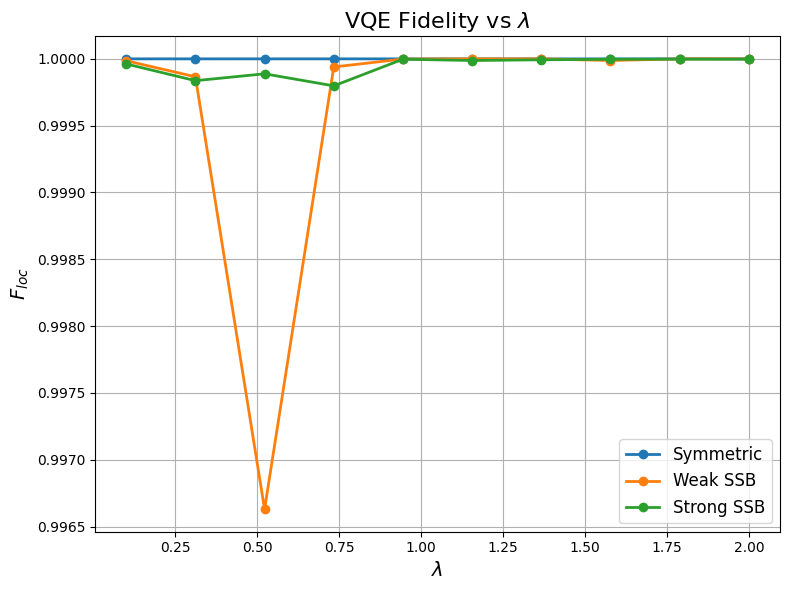

In [12]:
# ============================================================
# Plot : Fidelity vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Collect data
# ------------------------------------------------------------

cases = {}

for r in all_results:

    label = r['case']

    if label not in cases:

        cases[label] = {
            'lambda': [],
            'fidelity': []
        }

    cases[label]['lambda'].append(r['lambda'])
    cases[label]['fidelity'].append(r['fidelity'])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

for label, data in cases.items():

    plt.plot(
        data['lambda'],
        data['fidelity'],
        marker='o',
        linewidth=2,
        label=label
    )

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$F_{loc}$', fontsize=14)

plt.title(
    r'VQE Fidelity vs $\lambda$',
    fontsize=16
)

plt.grid(True)

plt.legend(fontsize=12)

plt.tight_layout()

plt.show()